# T10 — Paleobathymetry profile across the Atlantic at 50 Ma

**Half-space cooling, applied to a reconstructed age grid, is paleo-*basement* depth — not true paleobathymetry.** True paleobathymetry would require adding the sediment column on top of the basement; the GDH cooling model alone gives only the top of the oceanic crust as a function of age.

## What this notebook produces

A single chart panel showing a **long bathymetric profile** from the paleo-position of New York to the paleo-position of Lisbon at 50 Ma. The profile is extracted from a paleo-depth grid built by feeding the Zahirovic 2022 reconstructed age grid through the GDH half-space cooling model.

**Audience**: postgraduate / honours.  
**Difficulty**: ★★★.

## Learning objectives

- Sample a paleo-bathymetry raster along a great-circle profile across the central Atlantic.
- Reconstruct the profile endpoints to 50 Ma so the profile follows the paleo-margin, not the present-day one.
- Render the profile as a pyGMT cross-section alongside the source raster.


## Prerequisites and runtime

- **Plate model**: Zahirovic 2022.
- **Time**: 50 Ma.
- **Python**: `gplately`, `pygmt`, `pygplates`, `numpy`, `scipy`.
- **Runtime**: ~1 minute.


In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd, xarray as xr, gplately, pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration

User-tunable choices for this notebook. Edit the values below to change the model, snapshot time, region, or anchor plate without hunting through downstream code.


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME           = "Zahirovic2022"
RECONSTRUCTION_TIME  = 50.0          # Ma — central Atlantic at end-Eocene
ANCHOR_PLATE_ID      = 0
PROFILE_START        = (-70.0, 30.0)  # (lon, lat) — present-day GoM
PROFILE_END          = (-15.0, 30.0)  # (lon, lat) — present-day Sahara
# ============================================================================


In [3]:
# Cell 2 — load plate model + reconstruct profile endpoints
#
# Note on the unpacking order below: gplately's `Points.reconstruct(time,
# return_array=True)` returns *longitudes first*, then latitudes — the
# opposite of what the variable names might suggest at a glance. Unpacking
# the other way around is a silent bug (the profile renders in the wrong
# place). See the GPlately API-gotchas section in CLAUDE.md.
T = RECONSTRUCTION_TIME
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# Present-day NYC & Lisbon — reconstruct to T Ma
ENDS = gplately.Points(plate_reconstruction=recon,
                        lons=[-74.0, -9.1], lats=[40.7, 38.7],
                        plate_id=[101, 301])
end_lons, end_lats = ENDS.reconstruct(time=T, return_array=True)  # longitudes first per gplately convention
print(f"NYC paleo @ {T} Ma:    ({end_lats[0]:.1f}°N, {end_lons[0]:.1f}°E)")
print(f"Lisbon paleo @ {T} Ma: ({end_lats[1]:.1f}°N, {end_lons[1]:.1f}°E)")


NYC paleo @ 50.0 Ma:    (41.1°N, -60.6°E)
Lisbon paleo @ 50.0 Ma: (36.6°N, -11.8°E)


In [4]:
# Cell 2 — load age grid → paleo-basement depth (sediment-free)
age_file = model.get_raster("AgeGrids", time=T)
age_da = xr.open_dataarray(age_file) if str(age_file).endswith(".nc") \
         else xr.open_dataset(age_file).to_array().isel(variable=0)

def age_to_depth(a): return -(2500 + 350 * np.sqrt(np.clip(a, 0, None)))
depth_da = xr.apply_ufunc(age_to_depth, age_da)

### What the profile shows

Read the profile left-to-right. The two ends sit on the **continental margins** (shallow, near the paleo-shorelines of North America and Iberia). Walking inboard from either margin you cross the **continental shelf** edge and drop into deep ocean. The deep ocean reaches a maximum depth at ≈4 km below sea level. This is the old, cold crust that was created during early Atlantic opening (≈150 Ma).

The bathymetric **high in the middle** of the profile is the **paleo-mid-Atlantic ridge**: young, hot, buoyant crust sitting ≈2.5 km below sea level. The symmetry of the depth field about the ridge is the visual signature of symmetrical seafloor spreading.

Profile samples kept: 309 / 400 (dropped 91 NaN points)


/Users/dietmar/tmp/ipykernel_15040/1570564023.py:56: FutureWarning: The 'margin' parameter has been deprecated since v0.18.0 and will be removed in v0.20.0. Please use 'clearance' instead.


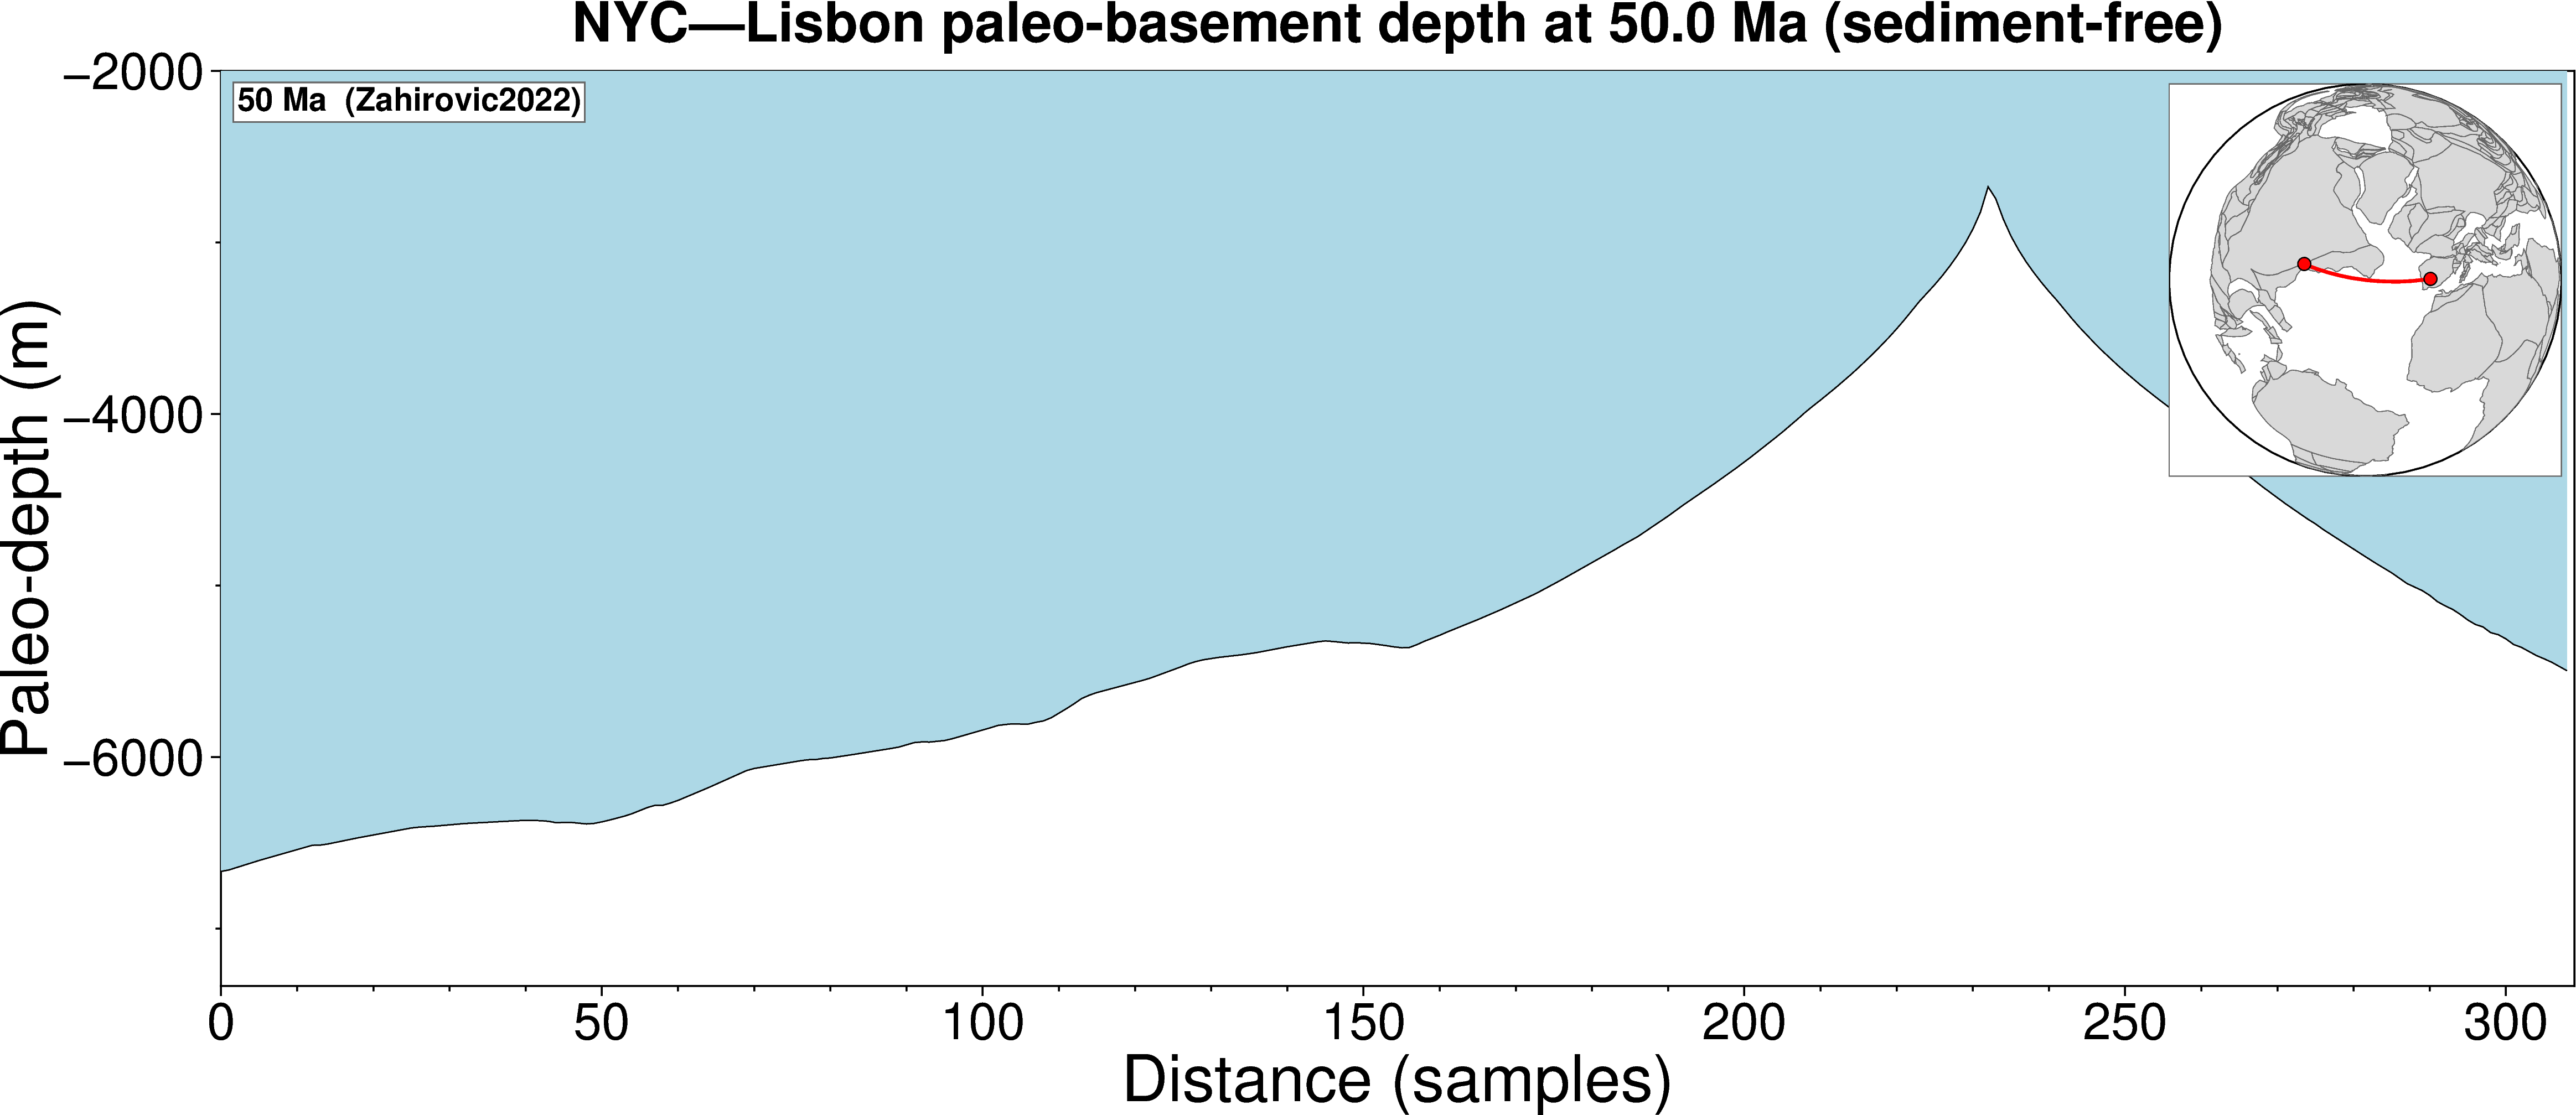

In [5]:
# Cell 3 — profile via pygmt.project + grdtrack
#
# `pygmt.grdtrack` only honours `newcolname` when `points` is a DataFrame
# with named columns. Passing a bare numpy.column_stack falls back to
# integer column labels (0, 1, 2), so `profile_track["depth"]` would
# raise KeyError. Build a named DataFrame to avoid that.
pts = pd.DataFrame({
    "lon": np.linspace(end_lons[0], end_lons[1], 400),
    "lat": np.linspace(end_lats[0], end_lats[1], 400),
})
profile_track = pygmt.grdtrack(
    points=pts, grid=depth_da, newcolname="depth",
)

# Drop samples where grdtrack returned NaN (continental crust or any
# masked region along the profile) so the filled polygon below can
# close cleanly — without this the line breaks wherever it crosses
# unmodelled crust.
profile_clean = profile_track.dropna(subset=["depth"]).reset_index(drop=True)
print(f"Profile samples kept: {len(profile_clean)} / {len(profile_track)} "
      f"(dropped {len(profile_track) - len(profile_clean)} NaN points)")

fig = pygmt.Figure()
# Bump axis-label and tick-label fonts well above the suite default —
# at 36 cm wide they look tiny otherwise.
with pygmt.config(FONT_LABEL="28p", FONT_ANNOT_PRIMARY="22p",
                  FONT_TITLE="24p"):
    fig.basemap(
        region=[0, len(profile_clean), profile_clean["depth"].min()*1.1, -2000],
        projection="X36c/14c",
        frame=["xaf+lDistance (samples)", "yaf+lPaleo-depth (m)",
               f"WSrt+tNYC—Lisbon paleo-basement depth at {T} Ma (sediment-free)"])
fig.plot(x=np.arange(len(profile_clean)), y=profile_clean["depth"],
         fill="lightblue", close="+yB", pen="0.5p,black")
fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  ({MODEL_NAME})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")

# Inset map (top-right) showing the paleo-position of the NYC–Lisbon transect
# at age T on the reconstructed paleo-Earth, so the reader can see WHERE on
# the globe the depth profile above is sampled.
try:
    _gplot_inset = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=float(T),
        plot_engine=gplately.PygmtPlotEngine(),
    )
    _xy_lons = np.linspace(end_lons[0], end_lons[1], 200)
    _xy_lats = np.linspace(end_lats[0], end_lats[1], 200)
    _mid_lon = float(np.mean(_xy_lons))
    _mid_lat = float(np.mean(_xy_lats))
    with fig.inset(position="jTR+w6c+o0.2c",
                   box="+gwhite+p0.4p,gray40", margin=0):
        fig.basemap(projection=f"G{_mid_lon}/{_mid_lat}/6c",
                    region="g", frame=["f"])
        try:
            fig.plot(data=_gplot_inset.get_continents(),
                     fill="gray85", pen="0.3p,gray40")
        except Exception:
            pass
        fig.plot(x=_xy_lons, y=_xy_lats, pen="1.5p,red")
        fig.plot(x=[_xy_lons[0], _xy_lons[-1]],
                 y=[_xy_lats[0], _xy_lats[-1]],
                 style="c0.20c", fill="red", pen="0.4p,black")
except Exception as _e:
    print(f"  (inset map skipped: {type(_e).__name__}: {_e})")

fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## What the figure shows

The 1-D bathymetric profile across a great-circle transect through the Atlantic at 50 Ma, sampled from the loaded plate model's reconstructed age grids and converted to depth via the half-space-cooling relation `depth = 2500 + 350·sqrt(age_Ma)`. Distance along the transect increases left-to-right.

Look for:

- A V-shape with the deepest points at either end of the transect (oldest crust, ~5500 m at 100 Ma age) and a shallow apex at the centre (the spreading ridge at zero age). The Mid-Atlantic Ridge sits at about 2500 m below sea level.
- A roughly symmetric profile, since crust on either side of the ridge has the same cooling history.
- Asymmetries flag ridge-jumps, hotspot interactions, or sampling artefacts where the great-circle transect cuts obliquely across an asymmetric ridge-flank.


## Extend this

- **Add sediment cover.** Layer a paleo-sediment-thickness grid on top of the basement to get true paleobathymetry.
- **Different age.** Re-render at 100 Ma (mid-Atlantic opening) or 20 Ma (fully opened) for comparison.
- **Switch cooling model.** Replace GDH with the plate-cooling model of Parsons & Sclater (1977) to see how the asymptotic depth limit changes the deep-basin signal.

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515

- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371-383. https://doi.org/10.1002/gdj3.146
- Stein, C.A. & Stein, S. (1992). A model for the global variation in oceanic depth and heat flow with lithospheric age. *Nature* 359, 123-129. https://doi.org/10.1038/359123a0